In [ ]:
# Run this cell to install all required dependencies (ideal for Google Colab Cloud or new environments)
!pip install pandas numpy matplotlib seaborn

# Multi-Agent System (MAS) - Performance & Resource Analysis

This notebook analyzes the execution and resource profiling logs generated by the MAS under the new metrics schema. It calculates animal-level processing metrics, overall system performance, and detailed hardware resource statistics (CPU, RAM, Temperature, and Power if available).

## Setup and Folder Path

In [22]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

### Select your Execution Mode:

**Option A: Local Runtime / Local Jupyter Notebook**
- If you are running Jupyter locally or connecting Colab to a local runtime, set the path below to your local reports folder.

**Option B: Google Colab Cloud Runtime**
- If you are running on Google's cloud server, run the upload cell below to upload `metrics.json`, `cpu.csv`, `mem.csv`, and `temp.csv`. The notebook will automatically set the correct folder path.

In [39]:
# OPTION A: Set your local folder path here
folder_path = "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T10:30:52.724627"
print(f"Default local path set to: {folder_path}")

Default local path set to: /Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T10:30:52.724627


In [38]:
# OPTION B: Run this cell if running on Google Colab Cloud Server to upload the metrics folder files
try:
    from google.colab import files
    import shutil
    
    print("Please upload metrics.json, cpu.csv, mem.csv, and temp.csv:")
    uploaded = files.upload()
    if uploaded:
        cloud_dir = "/content/metrics_logs"
        os.makedirs(cloud_dir, exist_ok=True)
        for filename in uploaded.keys():
            shutil.move(filename, os.path.join(cloud_dir, filename))
        folder_path = cloud_dir
        print(f"\nSuccessfully uploaded files! Setting folder_path to: {folder_path}")
except ImportError:
    print("Not running on Google Colab cloud. Using default local path.")

Not running on Google Colab cloud. Using default local path.


## 1. Load and Parse Capture and Prediction Metrics (`metrics.json`)

We parse the normalized metrics JSON file to calculate the following metrics:
- **Model Load Duration**: Time elapsed loading the model into memory.
- **By-Animal Lead Time**: Time elapsed from first image capture to the final weight prediction for each animal.
- **By-Animal Processing Delay**: The sum of model inference times for all selected suitable images for each animal.
- **By-Animal Latency**: Time elapsed from the last image capture to the final weight prediction for each animal.

In [40]:
with open(os.path.join(folder_path, "metrics.json"), "r") as f:
    metrics_data = json.load(f)

load_model_start = datetime.fromisoformat(metrics_data["load_model_start"])
load_model_final = datetime.fromisoformat(metrics_data["load_model_final"])
load_model_dur = load_model_final - load_model_start

print(f"PID: {metrics_data.get('pid', 'N/A')}")
print(f"Model Load Duration: {load_model_dur.total_seconds():.4f} seconds")

PID: mas-single_2026-06-18T10:30:52.724627
Model Load Duration: 0.0410 seconds


In [41]:
rows_animals = []
rows_imgs = []

for animal_id, info in metrics_data["animals"].items():
    first_cap = datetime.fromisoformat(info["first_image_capture_time"]) if info.get("first_image_capture_time") else None
    last_cap = datetime.fromisoformat(info["last_image_capture_time"]) if info.get("last_image_capture_time") else None
    total_imgs = info.get("total_of_images", 0)
    suitable_imgs = info.get("suitable_images", 0)
    pred_final = datetime.fromisoformat(info["weight_prediction_final"]) if info.get("weight_prediction_final") else None
    
    # Calculate durations safely
    lead_time = (pred_final - first_cap).total_seconds() if (pred_final and first_cap) else np.nan
    latency = (pred_final - last_cap).total_seconds() if (pred_final and last_cap) else np.nan
    
    proc_delays = []
    for img_idx, img_info in info.get("imgs", {}).items():
        if "weight_prediction_start" in img_info and "weight_prediction_final" in img_info:
            img_start = datetime.fromisoformat(img_info["weight_prediction_start"])
            img_final = datetime.fromisoformat(img_info["weight_prediction_final"])
            img_dur = (img_final - img_start).total_seconds()
            proc_delays.append(img_dur)
            
            rows_imgs.append({
                "animal_id": animal_id,
                "image_index": img_idx,
                "weight_prediction_start": img_start,
                "weight_prediction_final": img_final,
                "prediction_duration_sec": img_dur,
                "label": img_info.get("label")
            })
            
    total_proc_delay = sum(proc_delays) if proc_delays else 0.0
    
    rows_animals.append({
        "animal_id": animal_id,
        "first_image_capture_time": first_cap,
        "last_image_capture_time": last_cap,
        "weight_prediction_final": pred_final,
        "total_of_images": total_imgs,
        "suitable_images": suitable_imgs,
        "by_animal_lead_time_sec": lead_time,
        "by_animal_processing_delay_sec": total_proc_delay,
        "by_animal_latency_sec": latency
    })

df_animals = pd.DataFrame(rows_animals)
df_imgs = pd.DataFrame(rows_imgs)

print("Animals DataFrame:")
display(df_animals.head())
print("\nImages DataFrame:")
display(df_imgs.head())

Animals DataFrame:


,animal_id,first_image_capture_time,last_image_capture_time,weight_prediction_final,total_of_images,suitable_images,by_animal_lead_time_sec,by_animal_processing_delay_sec,by_animal_latency_sec
0,0002,2026-06-18 10:30:58.600636,2026-06-18 10:31:05.623716,2026-06-18 10:31:05.726791,71,9,7.126155,3.446084,0.103075
1,0005az,2026-06-18 10:31:05.825777,2026-06-18 10:31:22.326972,2026-06-18 10:31:22.429337,165,19,16.603560,7.090405,0.102365
2,0006,2026-06-18 10:31:22.527181,2026-06-18 10:31:33.703907,2026-06-18 10:31:33.806201,112,3,11.279020,0.640589,0.102294
3,000742,2026-06-18 10:31:33.904383,2026-06-18 10:31:44.270000,2026-06-18 10:31:44.373065,104,15,10.468682,8.149877,0.103065
4,0007vm,2026-06-18 10:31:44.470980,2026-06-18 10:31:52.325364,2026-06-18 10:31:52.428245,79,5,7.957265,1.323754,0.102881



Images DataFrame:


,animal_id,image_index,weight_prediction_start,weight_prediction_final,prediction_duration_sec,label
0,0002,45,2026-06-18 10:31:03.052412,2026-06-18 10:31:03.211362,0.158950,suited
1,0002,46,2026-06-18 10:31:03.155764,2026-06-18 10:31:03.369415,0.213651,suited
2,0002,47,2026-06-18 10:31:03.257399,2026-06-18 10:31:03.520339,0.262940,suited
3,0002,48,2026-06-18 10:31:03.364585,2026-06-18 10:31:03.678616,0.314031,suited
4,0002,49,2026-06-18 10:31:03.456771,2026-06-18 10:31:03.858753,0.401982,suited


### Animal-level Metrics & Averages

We calculate and plot the animal performance metrics showing the overall average thresholds clearly.

             ANIMAL METRICS AVERAGES               
Average Total Images per Animal: 90.01
Average Suitable (Suited) Images per Animal: 9.20
Average Lead Time per Animal: 9.1728 seconds
Average Prediction Processing Delay per Animal: 6.9133 seconds
Average Prediction Latency per Animal: 0.2048 seconds


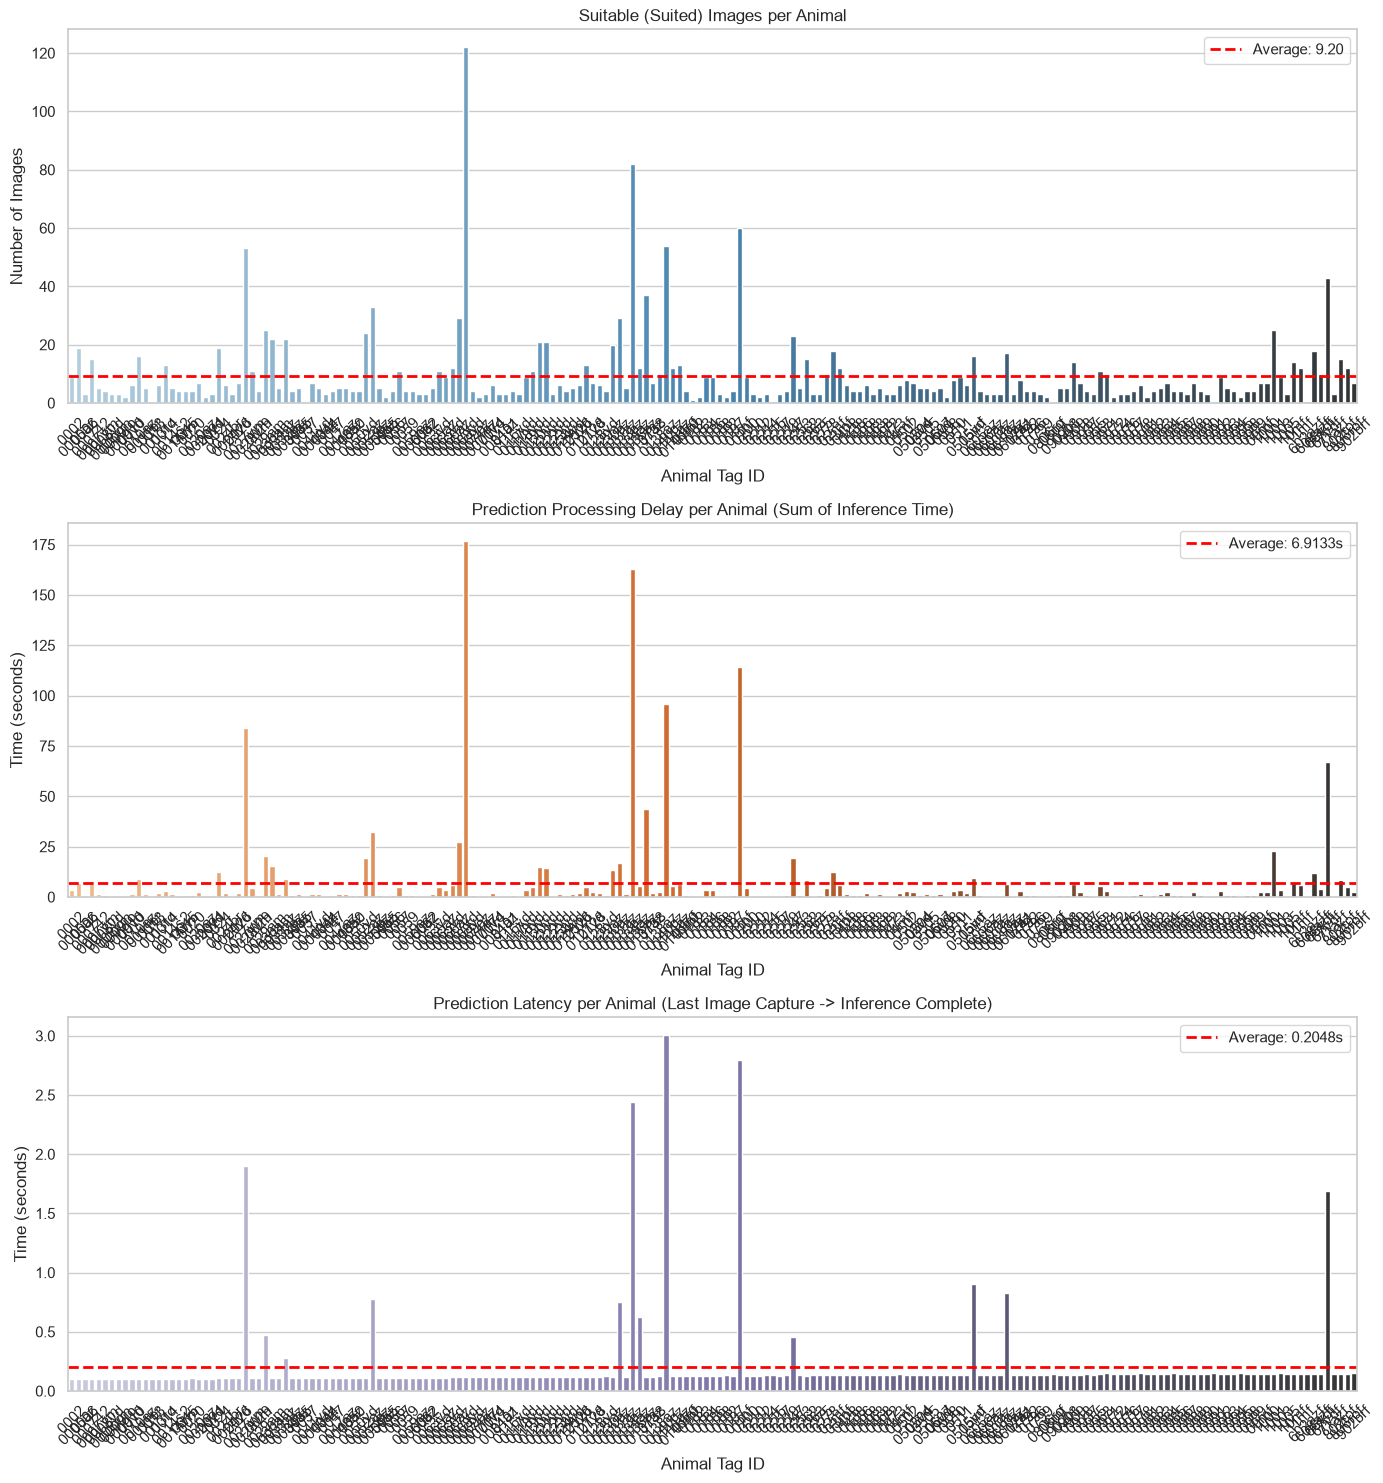

In [42]:
# Calculate averages explicitly
avg_total_imgs = df_animals["total_of_images"].mean()
avg_suitable_imgs = df_animals["suitable_images"].mean()
avg_lead_time = df_animals["by_animal_lead_time_sec"].mean()
avg_proc_delay = df_animals["by_animal_processing_delay_sec"].mean()
avg_latency = df_animals["by_animal_latency_sec"].mean()

print(f"===================================================")
print(f"             ANIMAL METRICS AVERAGES               ")
print(f"===================================================")
print(f"Average Total Images per Animal: {avg_total_imgs:.2f}")
print(f"Average Suitable (Suited) Images per Animal: {avg_suitable_imgs:.2f}")
print(f"Average Lead Time per Animal: {avg_lead_time:.4f} seconds")
print(f"Average Prediction Processing Delay per Animal: {avg_proc_delay:.4f} seconds")
print(f"Average Prediction Latency per Animal: {avg_latency:.4f} seconds")
print(f"===================================================")

# Create beautiful plots with average guidelines
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Plot 1: Suitable (Suited) Images
sns.barplot(data=df_animals, x="animal_id", y="suitable_images", ax=axes[0], palette="Blues_d", hue="animal_id", legend=False)
axes[0].axhline(avg_suitable_imgs, color="red", linestyle="--", linewidth=2, label=f"Average: {avg_suitable_imgs:.2f}")
axes[0].set_title("Suitable (Suited) Images per Animal")
axes[0].set_ylabel("Number of Images")
axes[0].set_xlabel("Animal Tag ID")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Plot 2: Processing Delay
sns.barplot(data=df_animals, x="animal_id", y="by_animal_processing_delay_sec", ax=axes[1], palette="Oranges_d", hue="animal_id", legend=False)
axes[1].axhline(avg_proc_delay, color="red", linestyle="--", linewidth=2, label=f"Average: {avg_proc_delay:.4f}s")
axes[1].set_title("Prediction Processing Delay per Animal (Sum of Inference Time)")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_xlabel("Animal Tag ID")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Plot 3: Latency
sns.barplot(data=df_animals, x="animal_id", y="by_animal_latency_sec", ax=axes[2], palette="Purples_d", hue="animal_id", legend=False)
axes[2].axhline(avg_latency, color="red", linestyle="--", linewidth=2, label=f"Average: {avg_latency:.4f}s")
axes[2].set_title("Prediction Latency per Animal (Last Image Capture -> Inference Complete)")
axes[2].set_ylabel("Time (seconds)")
axes[2].set_xlabel("Animal Tag ID")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

### Global Run Summary

- **Collection Lead Time**: Total run duration from the first image capture of the first animal to the final prediction of the last animal.
- **Mean Throughput**: The rate of animals processed per hour.
- **Overall Processed FPS**: Total number of images processed divided by the collection lead time.

In [43]:
overall_start = df_animals["first_image_capture_time"].min()
overall_end = df_animals["weight_prediction_final"].max()
collect_lead_time_sec = (overall_end - overall_start).total_seconds()
total_animals = len(df_animals["animal_id"].unique())
total_images = df_animals["total_of_images"].sum()

throughput = total_animals / (collect_lead_time_sec / 3600.0)
fps_rate = total_images / collect_lead_time_sec

print(f"Collection Start: {overall_start}")
print(f"Collection End: {overall_end}")
print(f"Collection Lead Time: {collect_lead_time_sec:.2f} seconds ({collect_lead_time_sec/60.0:.2f} minutes)")
print(f"Total Unique Animals: {total_animals}")
print(f"Total Images Processed: {total_images}")
print(f"Mean Throughput: {throughput:.2f} animals/hour")
print(f"Overall FPS: {fps_rate:.2f} frames/second")

Collection Start: 2026-06-18 10:30:58.600636
Collection End: 2026-06-18 11:00:28.133765
Collection Lead Time: 1769.53 seconds (29.49 minutes)
Total Unique Animals: 193
Total Images Processed: 17372
Mean Throughput: 392.65 animals/hour
Overall FPS: 9.82 frames/second


## 2. Resource Consumption Analysis

We load the CPU, RAM, and temperature logs to analyze consumption patterns, highlighting the mean value on every chart.

### CPU Usage

Overall Average CPU Usage: 19.53%


count    1767.000000
mean       19.533390
std        17.184895
min         0.000000
25%        10.300000
50%        11.825000
75%        16.662500
max        74.325000
Name: cpu_mean, dtype: float64

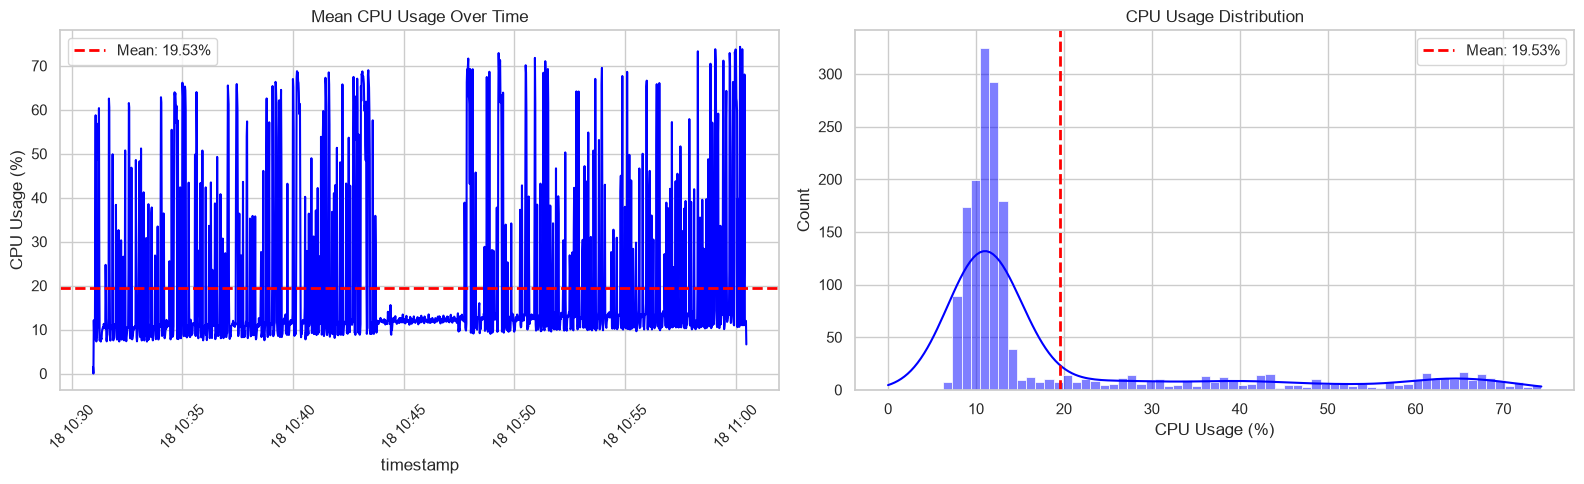

In [44]:
cpu_path = os.path.join(folder_path, "cpu.csv")
df_cpu = pd.read_csv(cpu_path)
df_cpu["timestamp"] = pd.to_datetime(df_cpu["timestamp"])

# Calculate mean usage across all cores
core_cols = [col for col in df_cpu.columns if col.startswith("cpu_core_")]
df_cpu["cpu_mean"] = df_cpu[core_cols].mean(axis=1)
cpu_avg = df_cpu["cpu_mean"].mean()

print(f"Overall Average CPU Usage: {cpu_avg:.2f}%")
display(df_cpu["cpu_mean"].describe())

# Plot CPU usage over time and distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=df_cpu, x="timestamp", y="cpu_mean", ax=axes[0], color="blue")
axes[0].axhline(cpu_avg, color="red", linestyle="--", linewidth=2, label=f"Mean: {cpu_avg:.2f}%")
axes[0].set_title("Mean CPU Usage Over Time")
axes[0].set_ylabel("CPU Usage (%)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.histplot(data=df_cpu, x="cpu_mean", kde=True, ax=axes[1], color="blue")
axes[1].axvline(cpu_avg, color="red", linestyle="--", linewidth=2, label=f"Mean: {cpu_avg:.2f}%")
axes[1].set_title("CPU Usage Distribution")
axes[1].set_xlabel("CPU Usage (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### RAM Usage

Overall Average Memory Usage: 5.71%


count    1769.000000
mean        5.709836
std         0.226208
min         4.800000
25%         5.500000
50%         5.700000
75%         5.900000
max         6.300000
Name: percent, dtype: float64

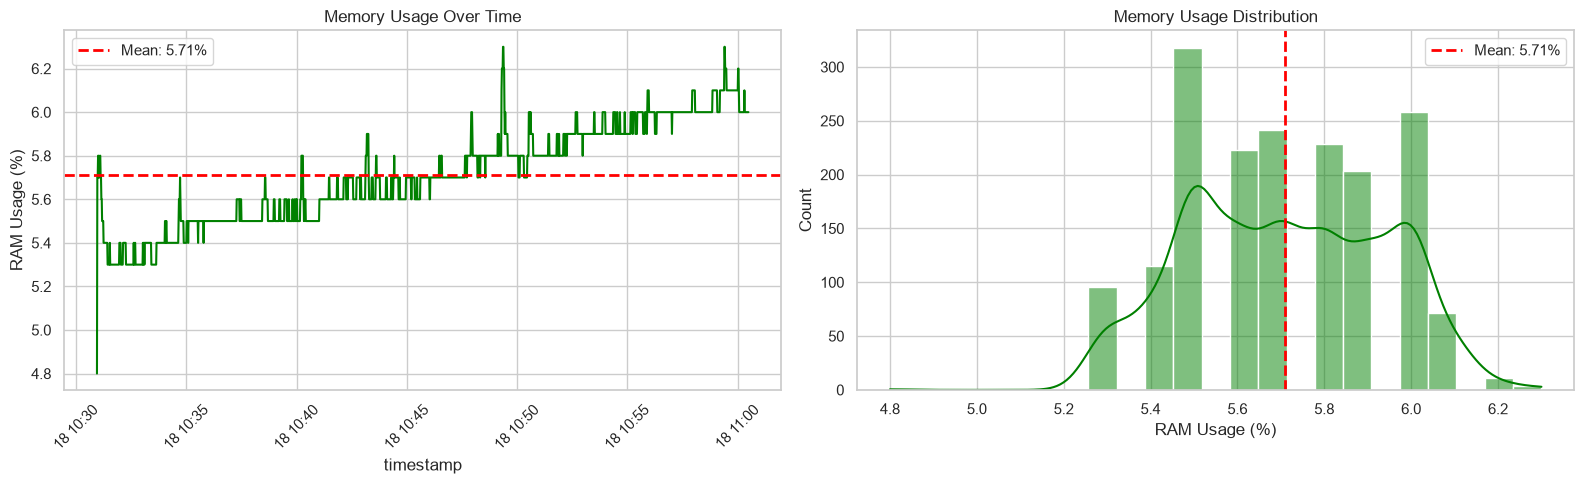

In [45]:
mem_path = os.path.join(folder_path, "mem.csv")
df_mem = pd.read_csv(mem_path)
df_mem["timestamp"] = pd.to_datetime(df_mem["timestamp"])
ram_avg = df_mem["percent"].mean()

print(f"Overall Average Memory Usage: {ram_avg:.2f}%")
display(df_mem["percent"].describe())

# Plot RAM usage over time and distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=df_mem, x="timestamp", y="percent", ax=axes[0], color="green")
axes[0].axhline(ram_avg, color="red", linestyle="--", linewidth=2, label=f"Mean: {ram_avg:.2f}%")
axes[0].set_title("Memory Usage Over Time")
axes[0].set_ylabel("RAM Usage (%)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.histplot(data=df_mem, x="percent", kde=True, ax=axes[1], color="green")
axes[1].axvline(ram_avg, color="red", linestyle="--", linewidth=2, label=f"Mean: {ram_avg:.2f}%")
axes[1].set_title("Memory Usage Distribution")
axes[1].set_xlabel("RAM Usage (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### SoC Temperature

Overall Average SoC Temperature: 63.74°C


count    1766.000000
mean       63.741166
std         3.583702
min        55.650000
25%        61.700000
50%        63.350000
75%        65.000000
max        78.200000
Name: temperature, dtype: float64

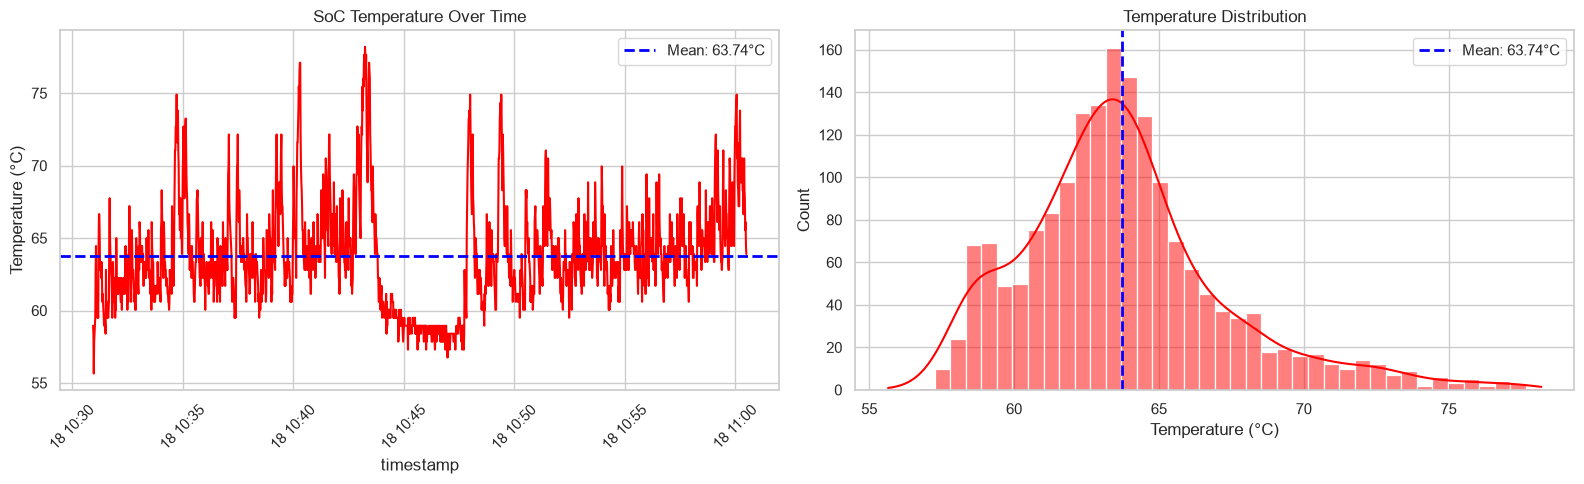

In [46]:
temp_path = os.path.join(folder_path, "temp.csv")
df_temp = pd.read_csv(temp_path)
df_temp["timestamp"] = pd.to_datetime(df_temp["timestamp"])
temp_avg = df_temp["temperature"].mean()

print(f"Overall Average SoC Temperature: {temp_avg:.2f}°C")
display(df_temp["temperature"].describe())

# Plot temperature over time and distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=df_temp, x="timestamp", y="temperature", ax=axes[0], color="red")
axes[0].axhline(temp_avg, color="blue", linestyle="--", linewidth=2, label=f"Mean: {temp_avg:.2f}°C")
axes[0].set_title("SoC Temperature Over Time")
axes[0].set_ylabel("Temperature (°C)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.histplot(data=df_temp, x="temperature", kde=True, ax=axes[1], color="red")
axes[1].axvline(temp_avg, color="blue", linestyle="--", linewidth=2, label=f"Mean: {temp_avg:.2f}°C")
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature (°C)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Power and Energy consumption (Optional)

In [ ]:
power_path = os.path.join(folder_path, "power.csv")
if os.path.exists(power_path):
    df_power = pd.read_csv(power_path)
    time_col = "timestamp" if "timestamp" in df_power.columns else "Datetime"
    df_power["timestamp"] = pd.to_datetime(df_power[time_col])
    df_power = df_power.sort_values("timestamp")
    
    # Calculate elapsed hours between consecutive measurements
    df_power["dt_hours"] = df_power["timestamp"].diff().dt.total_seconds() / 3600.0
    df_power["energy_Wh"] = df_power["Power[W]"] * df_power["dt_hours"]
    total_energy_wh = df_power["energy_Wh"].sum()
    power_avg = df_power["Power[W]"].mean()
    
    print("Power Consumption Statistics:")
    display(df_power["Power[W]"].describe())
    print(f"Total Energy Consumed: {total_energy_wh:.4f} Wh")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(data=df_power, x="timestamp", y="Power[W]", ax=axes[0], color="purple")
    axes[0].axhline(power_avg, color="red", linestyle="--", linewidth=2, label=f"Mean: {power_avg:.2f} W")
    axes[0].set_title("Power Consumption Over Time")
    axes[0].set_ylabel("Power (W)")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()

    sns.histplot(data=df_power, x="Power[W]", kde=True, ax=axes[1], color="purple")
    axes[1].axvline(power_avg, color="red", linestyle="--", linewidth=2, label=f"Mean: {power_avg:.2f} W")
    axes[1].set_title("Power Consumption Distribution")
    axes[1].set_xlabel("Power (W)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("power.csv not present in the log directory. Skipping power analysis.")